In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/artemmmtry/eth3d-dataset/val/undistorted/living_room/dslr_calibration_undistorted/images.txt
/kaggle/input/datasets/artemmmtry/eth3d-dataset/val/undistorted/living_room/dslr_calibration_undistorted/points3D.txt
/kaggle/input/datasets/artemmmtry/eth3d-dataset/val/undistorted/living_room/dslr_calibration_undistorted/cameras.txt
/kaggle/input/datasets/artemmmtry/eth3d-dataset/val/undistorted/living_room/images/dslr_images_undistorted/DSC_1549.JPG
/kaggle/input/datasets/artemmmtry/eth3d-dataset/val/undistorted/living_room/images/dslr_images_undistorted/DSC_1628.JPG
/kaggle/input/datasets/artemmmtry/eth3d-dataset/val/undistorted/living_room/images/dslr_images_undistorted/DSC_1622.JPG
/kaggle/input/datasets/artemmmtry/eth3d-dataset/val/undistorted/living_room/images/dslr_images_undistorted/DSC_1543.JPG
/kaggle/input/datasets/artemmmtry/eth3d-dataset/val/undistorted/living_room/images/dslr_images_undistorted/DSC_1582.JPG
/kaggle/input/datasets/artemmmtry/eth3d-dataset/v

In [29]:
import os, glob
import cv2
import numpy as np
import matplotlib.pyplot as plt

BASE = "/kaggle/input/datasets/artemmmtry/eth3d-dataset"
SCENE = "courtyard"

img_dir_candidates = glob.glob(os.path.join(BASE, "**", "undistorted", SCENE, "images/dslr_images_undistorted"), recursive=True)
cam_candidates = glob.glob(os.path.join(BASE, "**", "undistorted", SCENE, "dslr_calibration_undistorted/cameras.txt"), recursive=True)
imgtxt_candidates = glob.glob(os.path.join(BASE, "**", "undistorted", SCENE, "dslr_calibration_undistorted/images.txt"), recursive=True)

print("image dirs:", img_dir_candidates[:3])
print("cameras.txt:", cam_candidates[:3])
print("images.txt:", imgtxt_candidates[:3])

assert img_dir_candidates and cam_candidates and imgtxt_candidates, "Could not find ETH3D scene files."
IMG_DIR = img_dir_candidates[0]
CAM_TXT = cam_candidates[0]
IMG_TXT = imgtxt_candidates[0]

image dirs: ['/kaggle/input/datasets/artemmmtry/eth3d-dataset/train/undistorted/courtyard/images/dslr_images_undistorted']
cameras.txt: ['/kaggle/input/datasets/artemmmtry/eth3d-dataset/train/undistorted/courtyard/dslr_calibration_undistorted/cameras.txt']
images.txt: ['/kaggle/input/datasets/artemmmtry/eth3d-dataset/train/undistorted/courtyard/dslr_calibration_undistorted/images.txt']


In [31]:
def parse_cameras_txt(path):
    cams = {}
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            cam_id = int(parts[0])
            model = parts[1]
            width = int(parts[2])
            height = int(parts[3])
            params = list(map(float, parts[4:]))
            cams[cam_id] = {
                "model": model,
                "width": width,
                "height": height,
                "params": params,
            }
    return cams

def parse_images_txt(path):
    """
    ETH3D images.txt format:
      IMAGE_ID QW QX QY QZ TX TY TZ CAMERA_ID NAME
      followed by a 2D keypoint observation line (ignore it here)
    """
    meta = {}
    lines = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#"):
                lines.append(line)

    i = 0
    while i < len(lines):
        parts = lines[i].split()
        # image pose line has 10+ tokens and token 9 is the image name
        if len(parts) >= 10 and ("/" in parts[9] or "." in parts[9]):
            image_id = int(parts[0])
            qw, qx, qy, qz = map(float, parts[1:5])
            tx, ty, tz = map(float, parts[5:8])
            camera_id = int(parts[8])
            name = " ".join(parts[9:])
            meta[os.path.basename(name)] = {
                "image_id": image_id,
                "camera_id": camera_id,
                "q": np.array([qw, qx, qy, qz], dtype=np.float64),
                "t": np.array([tx, ty, tz], dtype=np.float64),
                "name": name,
            }
            i += 2  # skip the keypoint observation line
        else:
            i += 1
    return meta

cams = parse_cameras_txt(CAM_TXT)
meta = parse_images_txt(IMG_TXT)

print("num cameras:", len(cams))
print("num images:", len(meta))
print("camera ids:", list(cams.keys())[:5])

num cameras: 4
num images: 38
camera ids: [3, 2, 1, 0]


In [32]:
def K_from_camera(cam):
    # ETH3D undistorted images are pinhole; cameras.txt gives fx fy cx cy for that case.
    model = cam["model"].upper()
    params = cam["params"]

    if model == "PINHOLE" and len(params) >= 4:
        fx, fy, cx, cy = params[:4]
        K = np.array([[fx, 0, cx],
                      [0, fy, cy],
                      [0,  0,  1]], dtype=np.float64)
        return K

    raise ValueError(f"Unsupported camera model for this notebook: {model} with params={params}")

disk_images = sorted(glob.glob(os.path.join(IMG_DIR, "*")))
pairs = []

# collect disk files that exist in images.txt and share the same camera_id
valid = []
for p in disk_images:
    bn = os.path.basename(p)
    if bn in meta:
        valid.append((p, meta[bn]["camera_id"]))

for i in range(len(valid) - 1):
    p1, cam1 = valid[i]
    p2, cam2 = valid[i + 1]
    if cam1 == cam2:
        pairs = [(p1, p2, cam1)]
        break

assert pairs, "Could not find two consecutive images with the same camera_id."

img1_path, img2_path, camera_id = pairs[0]
K_full = K_from_camera(cams[camera_id])

print("img1:", os.path.basename(img1_path))
print("img2:", os.path.basename(img2_path))
print("camera_id:", camera_id)
print("K:\n", K_full)

img1: DSC_0286.JPG
img2: DSC_0287.JPG
camera_id: 1
K:
 [[3.40958e+03 0.00000e+00 3.11516e+03]
 [0.00000e+00 3.40944e+03 2.06473e+03]
 [0.00000e+00 0.00000e+00 1.00000e+00]]


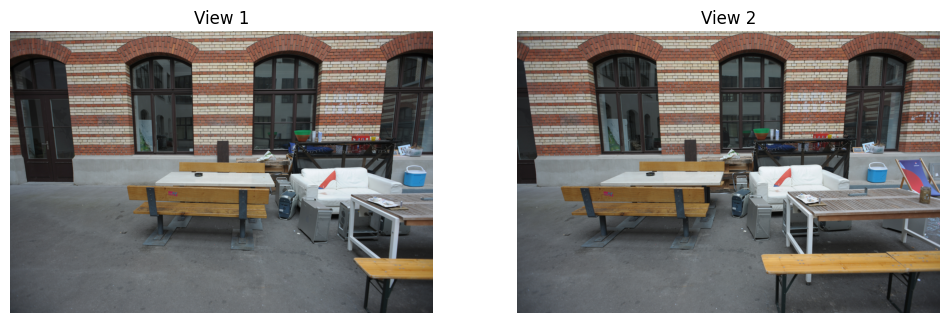

Scaled K:
 [[1.193353e+03 0.000000e+00 1.090306e+03]
 [0.000000e+00 1.193304e+03 7.226555e+02]
 [0.000000e+00 0.000000e+00 1.000000e+00]]


In [33]:
def load_rgb(path, scale=0.5):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if scale != 1.0:
        img = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
    return img

def scale_K(K, scale):
    Ks = K.copy().astype(np.float64)
    Ks[0, :] *= scale
    Ks[1, :] *= scale
    return Ks

scale = 0.35
img1 = load_rgb(img1_path, scale=scale)
img2 = load_rgb(img2_path, scale=scale)
K = scale_K(K_full, scale)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(img1); plt.axis("off"); plt.title("View 1")
plt.subplot(1,2,2); plt.imshow(img2); plt.axis("off"); plt.title("View 2")
plt.show()

print("Scaled K:\n", K)

keypoints: 5000 5000
good matches: 1774


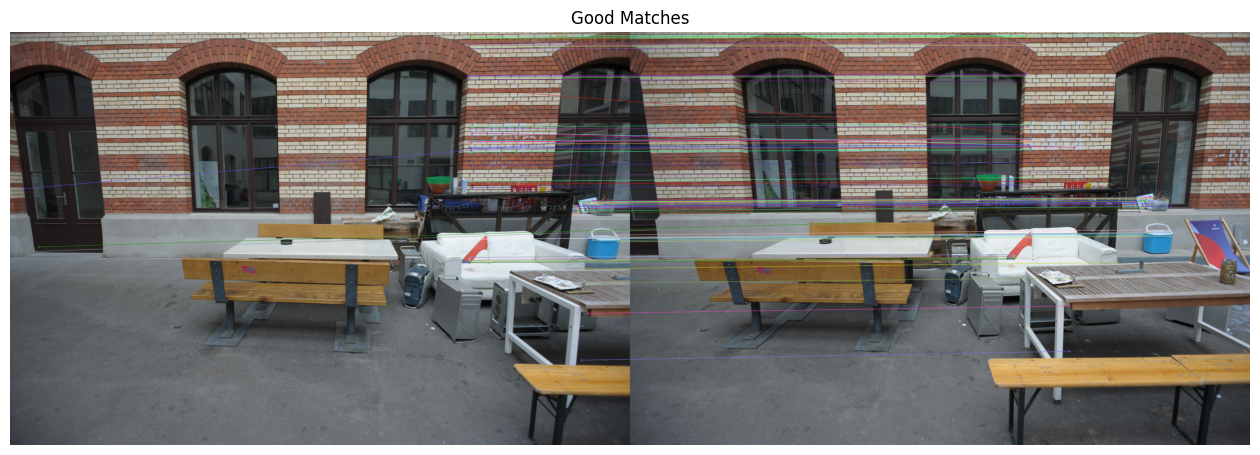

In [34]:
gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)

sift = cv2.SIFT_create(nfeatures=5000)
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

print("keypoints:", len(kp1), len(kp2))

bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append(m)

print("good matches:", len(good))

match_img = cv2.drawMatches(
    img1, kp1, img2, kp2, good[:80], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
plt.figure(figsize=(16,8))
plt.imshow(match_img)
plt.axis("off")
plt.title("Good Matches")
plt.show()

In [35]:
pts1 = np.float64([kp1[m.queryIdx].pt for m in good])
pts2 = np.float64([kp2[m.trainIdx].pt for m in good])

E, mask_E = cv2.findEssentialMat(
    pts1, pts2,
    cameraMatrix=K,
    method=cv2.RANSAC,
    prob=0.999,
    threshold=1.0
)

print("E inliers:", int(mask_E.sum()) if mask_E is not None else 0)

inlier_mask = mask_E.ravel().astype(bool)
pts1_in = pts1[inlier_mask]
pts2_in = pts2[inlier_mask]

_, R, t, mask_pose = cv2.recoverPose(E, pts1_in, pts2_in, cameraMatrix=K)

print("pose inliers:", int(mask_pose.sum()) if mask_pose is not None else 0)
print("R:\n", R)
print("t:\n", t)

E inliers: 1543
pose inliers: 393465
R:
 [[ 0.99893384  0.01361925 -0.04411011]
 [-0.01399434  0.9998684  -0.00820596]
 [ 0.04399255  0.0088145   0.99899297]]
t:
 [[-0.99954038]
 [ 0.02758412]
 [-0.01257548]]


In [36]:
pose_mask = mask_pose.ravel().astype(bool)
pts1_tri = pts1_in[pose_mask]
pts2_tri = pts2_in[pose_mask]

print("triangulation points:", len(pts1_tri))

P1 = K @ np.hstack((np.eye(3), np.zeros((3, 1))))
P2 = K @ np.hstack((R, t))

pts1_tri = np.ascontiguousarray(pts1_tri.reshape(-1, 2).T, dtype=np.float64)
pts2_tri = np.ascontiguousarray(pts2_tri.reshape(-1, 2).T, dtype=np.float64)
P1 = np.ascontiguousarray(P1, dtype=np.float64)
P2 = np.ascontiguousarray(P2, dtype=np.float64)

X_h = cv2.triangulatePoints(P1, P2, pts1_tri, pts2_tri)
points_3d = (X_h[:3] / X_h[3]).T

# keep only finite points and points in front of the camera
valid = np.isfinite(points_3d).all(axis=1)
points_3d = points_3d[valid]
print("valid 3D points:", len(points_3d))
print(points_3d[:5])

triangulation points: 1543
valid 3D points: 1543
[[ 4.64574431 -1.45522281  7.96279095]
 [ 3.34232192 -4.23347571  7.55436559]
 [ 6.80053364  0.09118258  7.80939728]
 [ 6.86374965  0.01035074  7.91745365]
 [ 7.06006068 -0.64840185  8.14718279]]


In [37]:
import open3d as o3d

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_3d)

o3d.visualization.draw_plotly([pcd])

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
